In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("GermanCredit.csv")

### Remove unnecessary apostrophes

In [32]:
df = df.replace("'", "", regex=True)

## Preprocessing

### Drop the 3 columns that contribute the least to the dataset

In [33]:
def drop_columns_with_most_none(data, n):
    none_counts = []
    for i, col in enumerate(data.columns):
        count = (data[col].astype(str).str.lower() == "none").sum()
        none_counts.append((col, count, i))
    
    none_counts.sort(key=lambda x: (-x[1], x[2]))
    cols_to_drop = [col for col, count, i in none_counts[:n]]
    
    return data.drop(columns=cols_to_drop), cols_to_drop

df, dropped_cols = drop_columns_with_most_none(df, 3)
print("Dropped columns:", dropped_cols)



Dropped columns: ['other_parties', 'other_payment_plans', 'own_telephone']


### Change checking_status categories

In [34]:
df["checking_status"] = df["checking_status"].replace({
    "no checking": "No Checking",
    "<0": "Low",
    "0<=X<200": "Medium",
    ">=200": "High"
})

### Change savings_status categories

In [35]:
df["savings_status"] = df["savings_status"].replace({
    "no known savings": "No Savings",
    "<100": "Low",
    "100<=X<500": "Medium",
    "500<=X<1000": "High",
    ">=1000": "High"
})

### Change class values from good to '1' and bad to '0'

In [36]:
df["class"] = df["class"].replace({
    "good": "1",
    "bad": "0"
})

### Change employment values to Unemployed, Amateur, Professional, Experienced, and Expert

In [37]:
df["employment"] = df["employment"].replace({
    "unemployed": "Unemployed",
    "<1": "Amateur",
    "1<=X<4": "Professional",
    "4<=X<7": "Experienced",
    ">=7": "Expert"
})

print("\nCleaned sample:")
print(df.head())

print("\nchecking_status unique values:")
print(df["checking_status"].unique())

print("\nsavings_status unique values:")
print(df["savings_status"].unique())

print("\nemployment unique values:")
print(df["employment"].unique())



Cleaned sample:
  checking_status  duration                  credit_history  \
0             Low         6  critical/other existing credit   
1          Medium        48                   existing paid   
2     No Checking        12  critical/other existing credit   
3             Low        42                   existing paid   
4             Low        24              delayed previously   

               purpose  credit_amount savings_status    employment  \
0             radio/tv           1169     No Savings        Expert   
1             radio/tv           5951            Low  Professional   
2            education           2096            Low   Experienced   
3  furniture/equipment           7882            Low   Experienced   
4              new car           4870            Low  Professional   

   installment_commitment     personal_status  residence_since  \
0                       4         male single                4   
1                       2  female div/dep/mar      

## Analysis

### Count of each category of foreign workers for each class of credit

In [38]:
print("\n1. Count of each category of foreign workers for each class of credit")
crosstab1 = pd.crosstab(df["foreign_worker"], df["class"])
print(crosstab1)


1. Count of each category of foreign workers for each class of credit
class             0    1
foreign_worker          
no                4   33
yes             296  667


### Count of each category of employment for each category of savings_status

In [39]:
print("\n2. Count of each category of employment for each category of savings_status")
crosstab2 = pd.crosstab(df["employment"], df["savings_status"])
print(crosstab2)



2. Count of each category of employment for each category of savings_status
savings_status  High  Low  Medium  No Savings
employment                                   
Amateur           12  120      17          23
Experienced       18  100      24          32
Expert            34  133      22          64
Professional      44  210      33          52
Unemployed         3   40       7          12


### Find the average credit_amount of single males that have 4<=X<7 years of employment

In [40]:
print("\n3. Average credit_amount of single males that have 4<=X<7 years of employment")
avg_credit_amount = df[
    (df["personal_status"] == "male single") &
    (df["employment"] == "Experienced")
]["credit_amount"].mean()
print(avg_credit_amount)


3. Average credit_amount of single males that have 4<=X<7 years of employment
4142.592592592592


### Find the average credit duration for each of the job types

In [41]:
print("\n4. Average credit duration for each of the job types")
avg_duration_by_job = df.groupby("job")["duration"].mean()
print(avg_duration_by_job)


4. Average credit duration for each of the job types
job
high qualif/self emp/mgmt    25.168919
skilled                      21.411111
unemp/unskilled non res      17.363636
unskilled resident           16.535000
Name: duration, dtype: float64


### For the purpose 'education', find the most common checking_status and savings_status

In [42]:
print("\n5. For the purpose education, most common checking_status and savings_status")
education_df = df[df["purpose"] == "education"]

most_common_checking = education_df["checking_status"].mode()[0]
most_common_savings = education_df["savings_status"].mode()[0]

print("Most common checking status:", most_common_checking)
print("Most common savings status:", most_common_savings)


5. For the purpose education, most common checking_status and savings_status
Most common checking status: No Checking
Most common savings status: Low


## Visualization

### Plot subplots of two bar charts: savings_status vs personal_status and checking_status vs personal_status

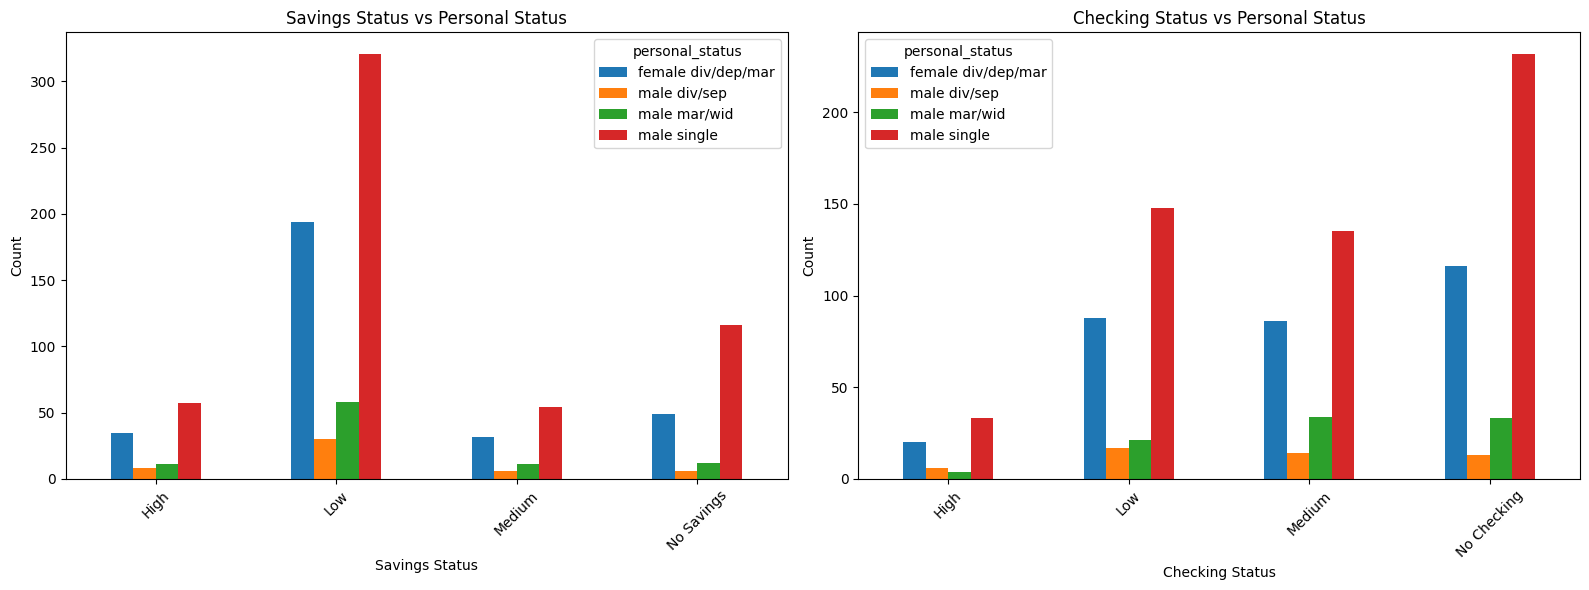

In [43]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pd.crosstab(df["savings_status"], df["personal_status"]).plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Savings Status vs Personal Status")
axes[0].set_xlabel("Savings Status")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

pd.crosstab(df["checking_status"], df["personal_status"]).plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Checking Status vs Personal Status")
axes[1].set_xlabel("Checking Status")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### For people having credit_amount more than 4000, plot property_magnitude vs average customer age

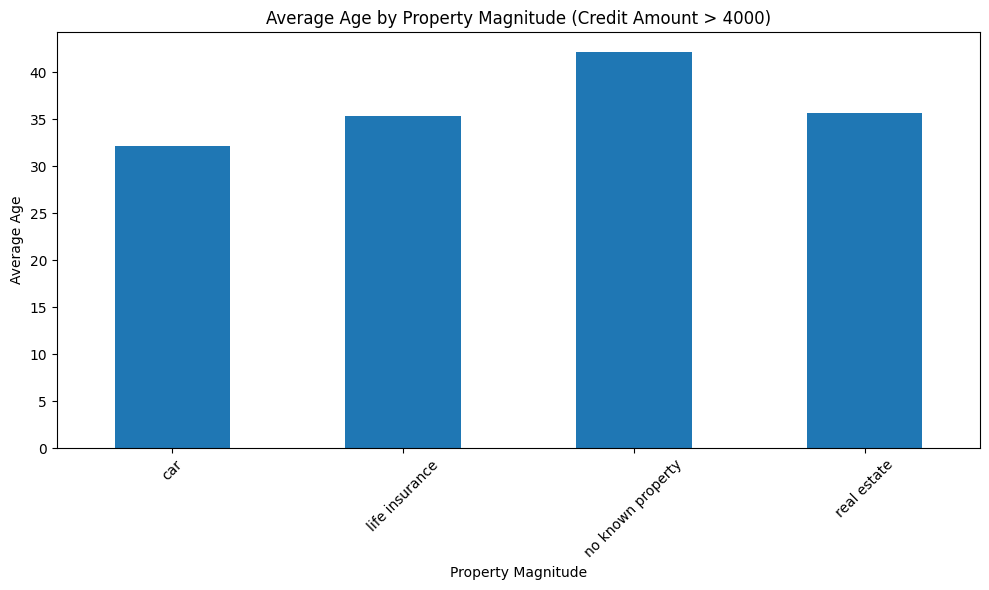

In [44]:
high_credit_df = df[df["credit_amount"] > 4000]
avg_age_by_property = high_credit_df.groupby("property_magnitude")["age"].mean()

plt.figure(figsize=(10, 6))
avg_age_by_property.plot(kind="bar")
plt.title("Average Age by Property Magnitude (Credit Amount > 4000)")
plt.xlabel("Property Magnitude")
plt.ylabel("Average Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### For people with a High savings_status and age above 40, plot pie charts for personal status, credit history, and job

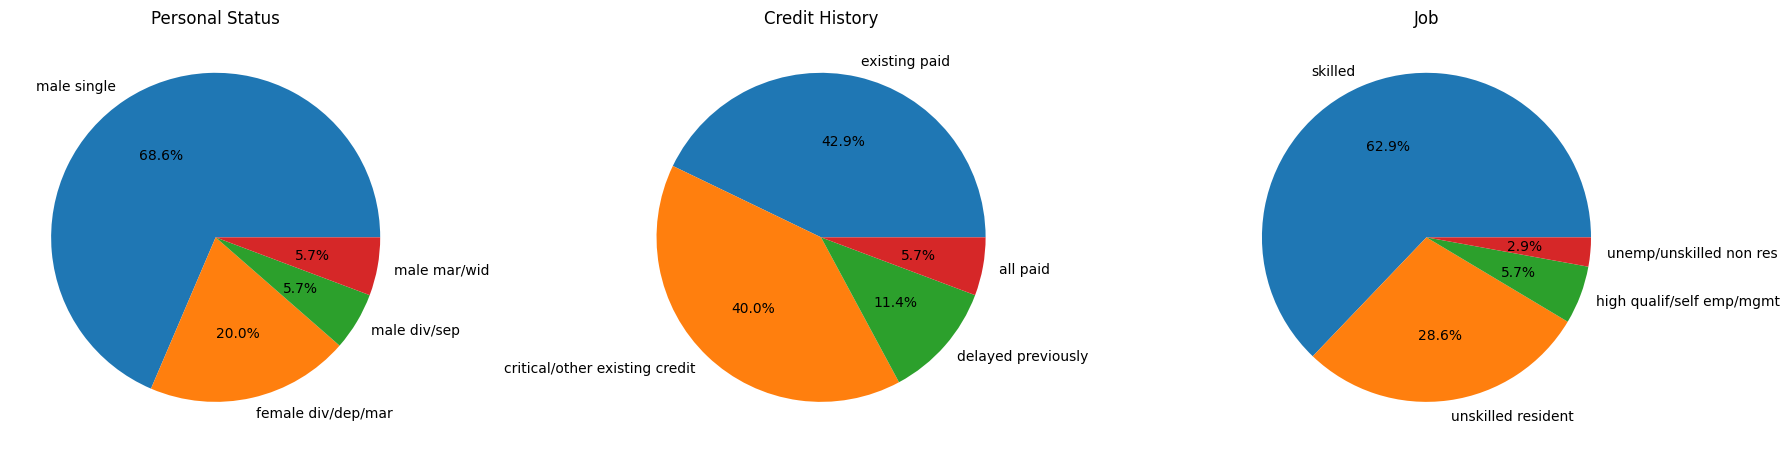

In [45]:
filtered_df = df[(df["savings_status"] == "High") & (df["age"] > 40)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

filtered_df["personal_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0]
)
axes[0].set_title("Personal Status")
axes[0].set_ylabel("")

filtered_df["credit_history"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1]
)
axes[1].set_title("Credit History")
axes[1].set_ylabel("")

filtered_df["job"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[2]
)
axes[2].set_title("Job")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()